# 📚 [LAB 11] 2. 상관분석

In [14]:
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr

In [1]:
origin = load_data("language_math_scores")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab11_/language_math_scores.xlsx
[desc] 어느 학급의 언어영역과 수리영역 점수를 기록한 가상의 데이터 셋

field     type    description
--------  ------  -------------
언어영역  INT     언어영역 점수
수리영역  INT     수리영역 점수


===== 데이터 크기 확인 =====
데이터셋 크기: (50, 2)
열 개수: 2
행 개수: 50

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   언어영역    50 non-null     int64
 1   수리영역    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes
None


,언어영역,수리영역
0,66,66
1,58,70
2,73,74
3,52,58
4,72,79


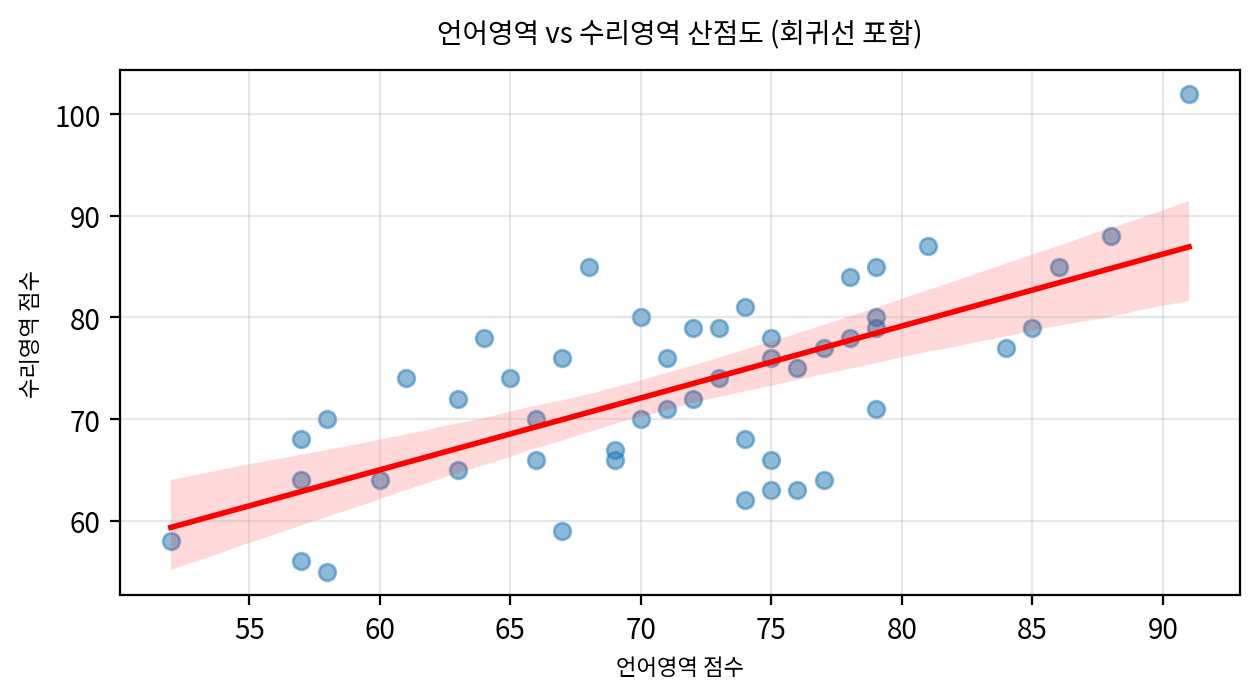

In [2]:
# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) Scatter Plot 그리기 (회귀선 포함)
sb.regplot(
    data=origin,
    x="언어영역",
    y="수리영역",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red", "linewidth": 2},
)
# 3) 그래프 꾸미기
ax.set_title("언어영역 vs 수리영역 산점도 (회귀선 포함)", fontsize=10, pad=10)
ax.set_xlabel("언어영역 점수", fontsize=8)
ax.set_ylabel("수리영역 점수", fontsize=8)
ax.grid(True, alpha=0.3)  # 배경 격자 표시
# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [9]:
x = origin["언어영역"]
y = origin["수리영역"]
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
reset = linear_reset(model, power=2, use_f=True)
# 선형성 적합 여부 (True=적합, False=부적합)
linearity_ok = reset.pvalue > 0.05

print(
    f"Ramsey RESET Test : {'선형성 적합' if linearity_ok else '선형성 위반'} (p-value: {reset.pvalue:.4f})"
)

Ramsey RESET Test : 선형성 적합 (p-value: 0.1884)


In [15]:
# 이상치와 왜도 검정
data = origin[["언어영역", "수리영역"]]
results = {}

for col in data.columns:
    temp = data[col].dropna()
    # 왜도 계산
    skew_original = temp.skew()
    # Z-score 기반 이상치 탐지 (|z| > 3)
    z_scores = zscore(temp)
    outlier_count = int(np.sum(np.abs(z_scores) > 3))
    # 로그 변환 후 왜도 계산 (음수 대비 +1)
    data_log = np.log1p(temp - temp.min() + 1)
    skew_log = data_log.skew()
    # 로그 변환 필요 여부 판단
    need_log = (abs(skew_original) > 1) and (abs(skew_log) < abs(skew_original))

    results[col] = {
        "original_skew": skew_original,
        "log_skew": skew_log,
        "outliers(|z|>3)": outlier_count,
        "log_recommended": need_log,
    }

results_df = pd.DataFrame(results).T
display(results_df)

# 이상치 점검 결과
outlier_flag = len((results_df["outliers(|z|>3)"] > 0)) > 0
if outlier_flag:
    print("이상치가 발견되어 스피어만 상관계수 사용")
else:
    print("이상치가 발견되지 않아 피어슨 상관계수 사용")

,original_skew,log_skew,outliers(|z|>3),log_recommended
언어영역,-0.102559,-1.735952,0,False
수리영역,0.367414,-1.529107,1,False


이상치가 발견되어 스피어만 상관계수 사용


In [16]:
pearson_r, pearson_p = pearsonr(origin["언어영역"], origin["수리영역"])
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(
    pearson_r, pearson_p, "대립" if pearson_p <= 0.05 else "귀무"
)

'statistic: 0.671, p-value: 0.000, 대립가설 채택'

In [18]:
spearman_r, spearman_p = spearmanr(origin["언어영역"], origin["수리영역"])
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(
    spearman_r, spearman_p, "대립" if spearman_p <= 0.05 else "귀무"
)

'statistic: 0.599, p-value: 0.000, 대립가설 채택'

In [19]:
# 1. 상관계수 선택
if linearity_ok and not outlier_flag:
    chosen = "pearson"
    corr, pval = pearson_r, pearson_p
    rationale = "선형성 만족 + 왜도/이상치 영향 작음으로 판단"
else:
    chosen = "spearman"
    corr, pval = spearman_r, spearman_p
    rationale = "비선형(또는 이상치 영향) 가능성 고려"
print("=" * 50)
print("📊 상관계수 요약")
print("=" * 50)
print(f"Pearson r: {pearson_r:.3f}, p-value: {pearson_p:.4f}")
print(f"Spearman rho: {spearman_r:.3f}, p-value: {spearman_p:.4f}")
print("\n" + "=" * 50)
print("✅ 최종 선택 결과")
print("=" * 50)
print(f"선택된 방법: {chosen}")
print(f"상관계수: {corr:.3f}")
print(f"p-value: {pval:.4f}")
print(f"선택 근거: {rationale}")
print("=" * 50)

📊 상관계수 요약
Pearson r: 0.671, p-value: 0.0000
Spearman rho: 0.599, p-value: 0.0000

✅ 최종 선택 결과
선택된 방법: spearman
상관계수: 0.599
p-value: 0.0000
선택 근거: 비선형(또는 이상치 영향) 가능성 고려


In [20]:
corr_matrix = origin[["언어영역", "수리영역"]].corr(method=chosen)
corr_matrix

,언어영역,수리영역
언어영역,1.000000,0.599095
수리영역,0.599095,1.000000


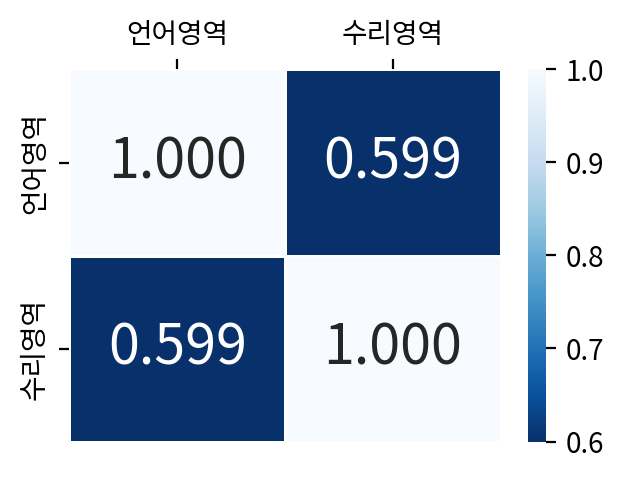

In [21]:
# 1) 그래프 초기화
width_px = 650  # 그래프 가로 크기
height_px = 500  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) heatmap 그리기
sb.heatmap(
    data=corr_matrix,
    annot=True,
    fmt="0.3f",
    linewidth=0.5,
    cmap="Blues_r",
    annot_kws={"size": 20},
)
# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()  # x축의 변수 이름을 상단으로 이동
# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [22]:
origin = load_data("baseball")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab11_/baseball.xlsx
[desc] 야구팀의 홈런수와 타율에 관한 자료 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (14, 2)
열 개수: 2
행 개수: 14

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   홈런수     14 non-null     int64  
 1   평균타율    14 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 356.0 bytes
None


,홈런수,평균타율
0,174,0.277
1,163,0.276
2,161,0.272
3,230,0.272
4,214,0.269


In [32]:
xname = "홈런수"
yname = "평균타율"
x = origin[xname]
y = origin[yname]
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
reset = linear_reset(model, power=2, use_f=True)
# 선형성 적합 여부 (True=적합, False=부적합)
linearity_ok = reset.pvalue > 0.05
print(
    f"Ramsey RESET Test : {'선형성 적합' if linearity_ok else '선형성 위반'} (p-value: {reset.pvalue:.4f})"
)

Ramsey RESET Test : 선형성 적합 (p-value: 0.0910)


In [33]:
# 이상치와 왜도 검정
data = origin[[xname, yname]]
results = {}

for col in data.columns:
    temp = data[col].dropna()
    # 왜도 계산
    skew_original = temp.skew()
    # Z-score 기반 이상치 탐지 (|z| > 3)
    z_scores = zscore(temp)
    outlier_count = int(np.sum(np.abs(z_scores) > 3))
    # 로그 변환 후 왜도 계산 (음수 대비 +1)
    data_log = np.log1p(temp - temp.min() + 1)
    skew_log = data_log.skew()
    # 로그 변환 필요 여부 판단
    need_log = (abs(skew_original) > 1) and (abs(skew_log) < abs(skew_original))

    results[col] = {
        "original_skew": skew_original,
        "log_skew": skew_log,
        "outliers(|z|>3)": outlier_count,
        "log_recommended": need_log,
    }

results_df = pd.DataFrame(results).T
display(results_df)

# 이상치 점검 결과
# outlier_flag = len(results_df[results_df["outliers(|z|>3)"] > 0]) > 0
outlier_flag = (results_df["outliers(|z|>3)"] > 0).any()
if outlier_flag:
    print("이상치가 발견되어 스피어만 상관계수 사용")
else:
    print("이상치가 발견되지 않아 피어슨 상관계수 사용")

,original_skew,log_skew,outliers(|z|>3),log_recommended
홈런수,0.512832,-0.97408,0,False
평균타율,0.220918,0.214929,0,False


이상치가 발견되지 않아 피어슨 상관계수 사용


In [34]:
report = f"본 분석에서는 {xname}과 {yname}간 상관관계를 검토하였다.\n\n"

# 1. 상관계수 선택
if linearity_ok and not outlier_flag:
    chosen = "pearson"
    corr, pval = pearson_r, pearson_p
    rationale = "선형성 만족 + 왜도/이상치 영향 작음으로 판단"
else:
    chosen = "spearman"
    corr, pval = spearman_r, spearman_p
    rationale = "비선형(또는 이상치 영향) 가능성 고려"
print("=" * 50)
print("📊 상관계수 요약")
print("=" * 50)
print(f"Pearson r: {pearson_r:.3f}, p-value: {pearson_p:.4f}")
print(f"Spearman rho: {spearman_r:.3f}, p-value: {spearman_p:.4f}")
print("\n" + "=" * 50)
print("✅ 최종 선택 결과")
print("=" * 50)
print(f"선택된 방법: {chosen}")
print(f"상관계수: {corr:.3f}")
print(f"p-value: {pval:.4f}")
print(f"선택 근거: {rationale}")
print("=" * 50)

📊 상관계수 요약
Pearson r: 0.671, p-value: 0.0000
Spearman rho: 0.599, p-value: 0.0000

✅ 최종 선택 결과
선택된 방법: pearson
상관계수: 0.671
p-value: 0.0000
선택 근거: 선형성 만족 + 왜도/이상치 영향 작음으로 판단


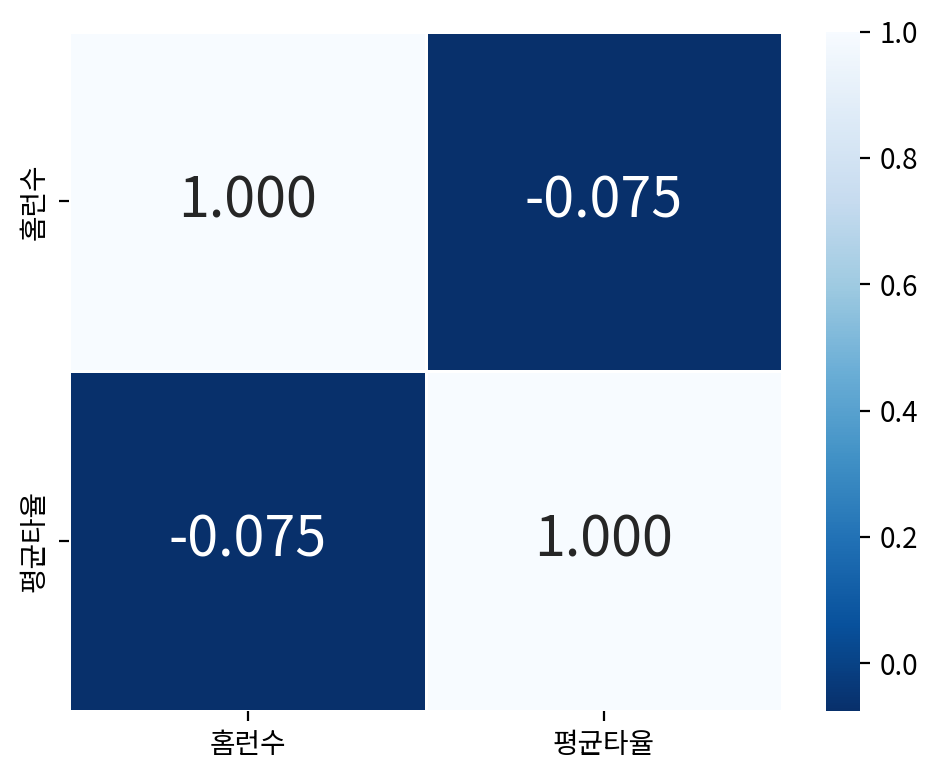

In [35]:
corr_matrix = origin[[xname, yname]].corr(method=chosen)

# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.heatmap(
    data=corr_matrix,
    annot=True,
    fmt="0.3f",
    linewidth=0.5,
    cmap="Blues_r",
    annot_kws={"size": 20},
)

# 3) 그래프 꾸미기 (필요시 제목/축 라벨 설정)
ax.set_title("", fontsize=12, pad=8)
ax.set_xlabel("", fontsize=8, labelpad=5)
ax.set_ylabel("", fontsize=8, labelpad=5)

plt.tight_layout()
plt.show()
plt.close()

In [36]:
origin = load_data("product")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab11_/product.xlsx
[desc] 어떤 원료의 품질특성(x)과 이 원료를 사용하여 만든 제품의 특성(y)에 관한 조사결과 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (10, 2)
열 개수: 2
행 개수: 10

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       10 non-null     int64
 1   y       10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None


,x,y
0,36,29
1,40,32
2,34,29
3,44,40
4,33,31


In [37]:
xname = "x"
yname = "y"
x = origin[xname]
y = origin[yname]
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
reset = linear_reset(model, power=2, use_f=True)
# 선형성 적합 여부 (True=적합, False=부적합)
linearity_ok = reset.pvalue > 0.05
print(
    f"Ramsey RESET Test : {'선형성 적합' if linearity_ok else '선형성 위반'} (p-value: {reset.pvalue:.4f})"
)

Ramsey RESET Test : 선형성 적합 (p-value: 0.1206)


In [38]:
# 이상치와 왜도 검정
data = origin[[xname, yname]]
results = {}

for col in data.columns:
    temp = data[col].dropna()
    # 왜도 계산
    skew_original = temp.skew()
    # Z-score 기반 이상치 탐지 (|z| > 3)
    z_scores = zscore(temp)
    outlier_count = int(np.sum(np.abs(z_scores) > 3))
    # 로그 변환 후 왜도 계산 (음수 대비 +1)
    data_log = np.log1p(temp - temp.min() + 1)
    skew_log = data_log.skew()
    # 로그 변환 필요 여부 판단
    need_log = (abs(skew_original) > 1) and (abs(skew_log) < abs(skew_original))

    results[col] = {
        "original_skew": skew_original,
        "log_skew": skew_log,
        "outliers(|z|>3)": outlier_count,
        "log_recommended": need_log,
    }

results_df = pd.DataFrame(results).T
display(results_df)

# 이상치 점검 결과
# outlier_flag = len(results_df[results_df["outliers(|z|>3)"] > 0]) > 0
outlier_flag = (results_df["outliers(|z|>3)"] > 0).any()
if outlier_flag:
    print("이상치가 발견되어 스피어만 상관계수 사용")
else:
    print("이상치가 발견되지 않아 피어슨 상관계수 사용")

,original_skew,log_skew,outliers(|z|>3),log_recommended
x,-0.340387,-2.178627,0,False
y,1.168124,-1.066498,0,True


이상치가 발견되지 않아 피어슨 상관계수 사용


In [39]:
report = f"본 분석에서는 {xname}과 {yname}간 상관관계를 검토하였다.\n\n"

# 1. 상관계수 선택
if linearity_ok and not outlier_flag:
    chosen = "pearson"
    corr, pval = pearson_r, pearson_p
    rationale = "선형성 만족 + 왜도/이상치 영향 작음으로 판단"
else:
    chosen = "spearman"
    corr, pval = spearman_r, spearman_p
    rationale = "비선형(또는 이상치 영향) 가능성 고려"
print("=" * 50)
print("📊 상관계수 요약")
print("=" * 50)
print(f"Pearson r: {pearson_r:.3f}, p-value: {pearson_p:.4f}")
print(f"Spearman rho: {spearman_r:.3f}, p-value: {spearman_p:.4f}")
print("\n" + "=" * 50)
print("✅ 최종 선택 결과")
print("=" * 50)
print(f"선택된 방법: {chosen}")
print(f"상관계수: {corr:.3f}")
print(f"p-value: {pval:.4f}")
print(f"선택 근거: {rationale}")
print("=" * 50)

📊 상관계수 요약
Pearson r: 0.671, p-value: 0.0000
Spearman rho: 0.599, p-value: 0.0000

✅ 최종 선택 결과
선택된 방법: pearson
상관계수: 0.671
p-value: 0.0000
선택 근거: 선형성 만족 + 왜도/이상치 영향 작음으로 판단


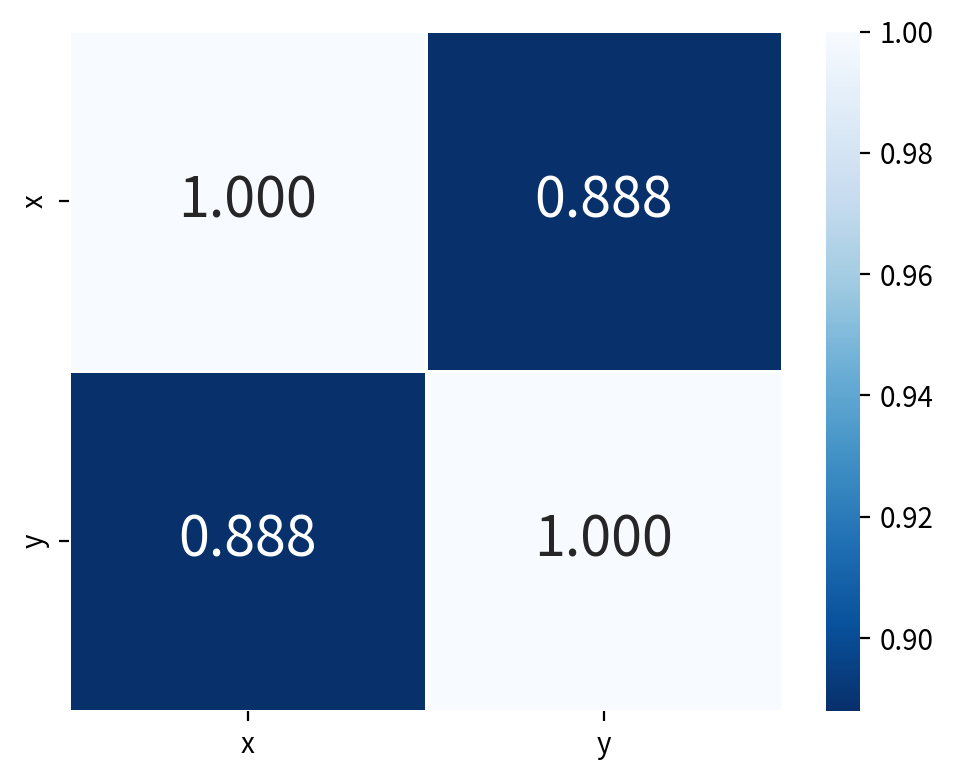

In [40]:
corr_matrix = origin[[xname, yname]].corr(method=chosen)

# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.heatmap(
    data=corr_matrix,
    annot=True,
    fmt="0.3f",
    linewidth=0.5,
    cmap="Blues_r",
    annot_kws={"size": 20},
)

# 3) 그래프 꾸미기 (필요시 제목/축 라벨 설정)
ax.set_title("", fontsize=12, pad=8)
ax.set_xlabel("", fontsize=8, labelpad=5)
ax.set_ylabel("", fontsize=8, labelpad=5)

plt.tight_layout()
plt.show()
plt.close()

In [41]:
origin = load_data("study_time")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab11_/study_time.xlsx
[desc] 학생들에 대한 공부 시간과 성적 데이터 (출처: 방송통신대학교 통계학 개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (10, 2)
열 개수: 2
행 개수: 10

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   공부시간    10 non-null     int64
 1   성적      10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None


,공부시간,성적
0,2,65
1,4,85
2,3,75
3,5,90
4,6,95


Ramsey RESET Test : 선형성 적합 (p-value: 0.4234)


,original_skew,log_skew,outliers(|z|>3)
공부시간,0.000000,-0.762678,0.0
성적,-0.136348,-1.573659,0.0


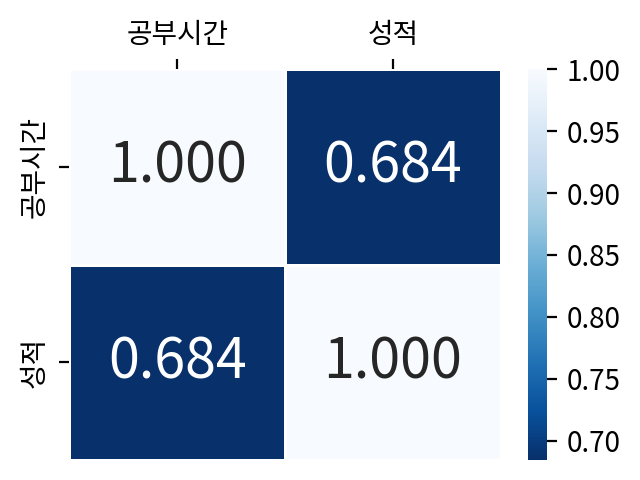

본 분석에서는 공부시간과 성적 간 상관관계를 검토하였다.

데이터 점검 결과, 두 변수의 관계는 선형적이며 이상치의 영향도 크지 않아 피어슨 상관계수를 사용하였다.

분석 결과, 피어슨 상관계수는 r = 0.684, p = 0.029(으)로 나타나 두 변수 간 양의 상관 관계가 통계적으로 유의함을 확인하였다.


In [43]:
xname = "공부시간"
yname = "성적"

# ---------------------------------
# 선형성 가정 확인 (Ramsey RESET)
# ---------------------------------
x = origin[xname]
y = origin[yname]
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
reset = linear_reset(model, power=2, use_f=True)
# 선형성 적합 여부 (True=적합, False=부적합)
linearity_ok = reset.pvalue > 0.05
print(
    f"Ramsey RESET Test : {'선형성 적합' if linearity_ok else '선형성 위반'} (p-value: {reset.pvalue:.4f})"
)

# ---------------------------------
# 이상치와 왜도 검정
# ---------------------------------
data = origin[[xname, yname]]
results = {}

for col in data.columns:
    temp = data[col].dropna()
    # 왜도 계산
    skew_original = temp.skew()
    # Z-score 기반 이상치 탐지 (|z| > 3)
    z_scores = zscore(temp)
    outlier_count = int(np.sum(np.abs(z_scores) > 3))
    # 로그 변환 후 왜도 계산 (음수 대비 +1)
    data_log = np.log1p(temp - temp.min() + 1)
    skew_log = data_log.skew()

    results[col] = {
        "original_skew": skew_original,
        "log_skew": skew_log,
        "outliers(|z|>3)": outlier_count,
    }

results_df = DataFrame(results).T
display(results_df)

# 이상치 점검 결과
outlier_flag = (results_df["outliers(|z|>3)"] > 0).any()

# ---------------------------------
# 상관분석 + 보고서 텍스트 생성
# ---------------------------------
report = f"본 분석에서는 {xname}과 {yname} 간 상관관계를 검토하였다.\n\n"

if linearity_ok and not outlier_flag:
    chosen = "pearson"
    corr, pval = pearsonr(origin[xname], origin[yname])
    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        direction = "양의 상관" if corr > 0 else "음의 상관"
        report += (
            "데이터 점검 결과, 두 변수의 관계는 선형적이며 이상치의 영향도 크지 않아 피어슨 상관계수를 사용하였다.\n\n"
            f"분석 결과, 피어슨 상관계수는 r = {corr:0.3f}, p = {pval:0.3f}(으)로 나타나 두 변수 간 {direction} 관계가 통계적으로 유의함을 확인하였다."
        )
else:
    chosen = "spearman"
    corr, pval = spearmanr(origin[xname], origin[yname])
    if pval > 0.05:
        report += "데이터 점검 결과, 두 변수의 관계는 통계적으로 유의하지 않았다."
    else:
        direction = "양의 단조" if corr > 0 else "음의 단조"
        report += (
            "데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 스피어만 상관계수를 사용하였다.\n\n"
            f"분석 결과, 스피어만 상관계수는 r = {corr:0.3f}, p = {pval:0.3f}(으)로 나타나 두 변수 간 {direction} 관계가 존재함을 확인하였다."
        )

# ---------------------------------
# 결과 시각화 (상관행렬 히트맵)
# ---------------------------------
corr_matrix = origin[[xname, yname]].corr(method=chosen)

# 1) 그래프 초기화
width_px = 650  # 그래프 가로 크기
height_px = 500  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) heatmap 그리기
sb.heatmap(
    data=corr_matrix,
    annot=True,
    fmt="0.3f",
    linewidth=0.5,
    cmap="Blues_r",
    annot_kws={"size": 20},
)

# 3) 그래프 꾸미기
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()  # x축의 변수 이름을 상단으로 이동

# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

# ---------------------------------
# 결과 보고 출력
# ---------------------------------
print(report)